# Edge Weight Pattern Analysis

Investigating edge weight distributions in Topology Zoo networks to understand why some networks generalize well while others fail catastrophically.


In [10]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from collections import defaultdict
from scipy import stats
import os

# Set style
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

# Determine project root - try multiple strategies
# Strategy 1: Check if we're in notebooks directory
cwd = Path.cwd()
if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
# Strategy 2: Look for results directory in current or parent
elif (cwd / "results" / "evaluation_results.json").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "results" / "evaluation_results.json").exists():
    PROJECT_ROOT = cwd.parent
# Strategy 3: Default to parent if notebooks exists
elif (cwd.parent / "notebooks").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

print(f"Project root: {PROJECT_ROOT}")
print(f"Current working directory: {cwd}")

# Load evaluation results
results_file = PROJECT_ROOT / "results" / "evaluation_results.json"
if not results_file.exists():
    raise FileNotFoundError(f"Could not find results file at {results_file}")

with open(results_file) as f:
    results = json.load(f)

networks = results["topology_zoo"]["per_network"]

# Sort by MAPE
networks_sorted = sorted(networks, key=lambda x: x["mape"])

# Get top 10 best and worst
best_10 = networks_sorted[:10]
worst_10 = networks_sorted[-10:]

print(f"Loaded {len(networks)} networks")
print(f"Best 10 MAPE range: {best_10[0]['mape']:.2f}% - {best_10[-1]['mape']:.2f}%")
print(f"Worst 10 MAPE range: {worst_10[0]['mape']:.2f}% - {worst_10[-1]['mape']:.2f}%")

Project root: /Users/oliver/code/gnn-network-routing
Current working directory: /Users/oliver/code/gnn-network-routing/notebooks
Loaded 66 networks
Best 10 MAPE range: 35.79% - 141.34%
Worst 10 MAPE range: 1879.79% - 4311.07%


## Load Graph Data and Extract Edge Weights


In [11]:
from gnn_routing.data import load_topology_zoo_networks


def load_network_graphs(network_list):
    """Load NetworkX graphs for a list of networks."""
    graphs = {}
    for network_info in network_list:
        name = network_info["name"]
        # File path from results is relative to project root
        file_path_str = network_info["file"]

        # Resolve path relative to project root
        if Path(file_path_str).is_absolute():
            file_path = Path(file_path_str)
        else:
            file_path = PROJECT_ROOT / file_path_str

        try:
            if not file_path.exists():
                # Try alternative path resolution
                alt_path = (
                    PROJECT_ROOT
                    / "data"
                    / "topology_zoo"
                    / "graphml"
                    / f"{name}.graphml"
                )
                if alt_path.exists():
                    file_path = alt_path
                else:
                    raise FileNotFoundError(
                        f"Could not find graph file for {name} at {file_path} or {alt_path}"
                    )

            G = nx.read_graphml(file_path)
            # Convert to undirected if needed
            if G.is_directed():
                G = G.to_undirected()
            graphs[name] = G
        except Exception as e:
            print(f"Error loading {name}: {e}")

    return graphs


# Load graphs for best and worst performers
print("Loading best performing networks...")
best_graphs = load_network_graphs(best_10)
print(f"Loaded {len(best_graphs)} best networks")

print("\nLoading worst performing networks...")
worst_graphs = load_network_graphs(worst_10)
print(f"Loaded {len(worst_graphs)} worst networks")

Loading best performing networks...
Loaded 10 best networks

Loading worst performing networks...
Loaded 10 worst networks


## Extract Edge Weights


In [12]:
def extract_edge_weights(G):
    """Extract edge weights from a NetworkX graph."""
    weights = []
    
    if G.number_of_edges() == 0:
        return np.array([])

    for u, v, data in G.edges(data=True):
        # Try different possible weight attributes
        weight = None

        # Common weight attribute names
        for attr in ["weight", "Weight", "length", "Length", "cost", "Cost", "delay", "Delay"]:
            if attr in data:
                weight = data[attr]
                break

        # If no weight found, check if it's a numeric value
        if weight is None:
            # Check if there's any numeric attribute
            for key, value in data.items():
                if isinstance(value, (int, float)) and not isinstance(value, bool):
                    weight = value
                    break

        # Default to 1.0 if no weight found
        if weight is None:
            weight = 1.0

        # Convert to float if needed
        try:
            weight = float(weight)
            if weight > 0:  # Only include positive weights
                weights.append(weight)
        except (ValueError, TypeError):
            weights.append(1.0)  # Default

    return np.array(weights)


# Extract weights for all networks
best_weights = {}
worst_weights = {}

print("Extracting weights from best performing networks...")
for name, G in best_graphs.items():
    weights = extract_edge_weights(G)
    best_weights[name] = weights
    if len(weights) > 0:
        print(
            f"{name}: {len(weights)} edges, weight range: [{weights.min():.4f}, {weights.max():.4f}], mean: {weights.mean():.4f}"
        )
    else:
        print(f"{name}: {G.number_of_edges()} edges, but no weights extracted (using default 1.0)")
        # Use default weight of 1.0 for all edges
        weights = np.ones(G.number_of_edges())
        best_weights[name] = weights

print("\n" + "=" * 80 + "\n")

print("Extracting weights from worst performing networks...")
for name, G in worst_graphs.items():
    weights = extract_edge_weights(G)
    worst_weights[name] = weights
    if len(weights) > 0:
        print(
            f"{name}: {len(weights)} edges, weight range: [{weights.min():.4f}, {weights.max():.4f}], mean: {weights.mean():.4f}"
        )
    else:
        print(f"{name}: {G.number_of_edges()} edges, but no weights extracted (using default 1.0)")
        # Use default weight of 1.0 for all edges
        weights = np.ones(G.number_of_edges())
        worst_weights[name] = weights

Extracting weights from best performing networks...
Iris: 64 edges, but no weights extracted (using default 1.0)
Esnet: 23 edges, weight range: [1.0000, 10000000000.0000], mean: 3486956522.3478
Forthnet: 3 edges, weight range: [11000000000.0000, 28000000000.0000], mean: 18000000000.0000
Columbus: 85 edges, but no weights extracted (using default 1.0)
Pern: 129 edges, but no weights extracted (using default 1.0)
Uninett2010: 98 edges, weight range: [1000000000.0000, 10000000000.0000], mean: 2545918367.3469
Cesnet201006: 11 edges, weight range: [100000000.0000, 10000000000.0000], mean: 2800000000.0000
Surfnet: 5 edges, weight range: [1.0000, 1.0000], mean: 1.0000
Telcove: 70 edges, but no weights extracted (using default 1.0)
Sinet: 2 edges, weight range: [40000000000.0000, 40000000000.0000], mean: 40000000000.0000


Extracting weights from worst performing networks...
Garr201102: 68 edges, weight range: [1.0000, 20000000000.0000], mean: 2554808823.5441
Interoute: 10 edges, weight range:

In [13]:
# Diagnostic: Check which networks have no weights and inspect their edge attributes
print("=" * 80)
print("DIAGNOSTIC: Networks with missing weights")
print("=" * 80)

all_graphs = {**best_graphs, **worst_graphs}
all_weights = {**best_weights, **worst_weights}

networks_without_weights = []
for name, G in all_graphs.items():
    weights = all_weights.get(name, np.array([]))
    if len(weights) == 0 and G.number_of_edges() > 0:
        networks_without_weights.append(name)

if networks_without_weights:
    print(f"\nFound {len(networks_without_weights)} networks without extracted weights:")
    for name in networks_without_weights:
        G = all_graphs[name]
        print(f"\n{name}:")
        print(f"  Edges: {G.number_of_edges()}")
        if G.number_of_edges() > 0:
            # Check first edge attributes
            first_edge = list(G.edges(data=True))[0]
            print(f"  First edge attributes: {first_edge[2]}")
            # Check all unique attribute keys across edges
            all_attrs = set()
            for u, v, data in G.edges(data=True):
                all_attrs.update(data.keys())
            print(f"  All edge attribute keys: {sorted(all_attrs)}")
else:
    print("\nAll networks have weights extracted successfully!")


DIAGNOSTIC: Networks with missing weights

All networks have weights extracted successfully!


## Compare Edge Weight Statistics


In [14]:
def compute_weight_stats(weights_dict):
    """Compute statistics for edge weights."""
    stats_list = []

    for name, weights in weights_dict.items():
        if len(weights) == 0:
            continue

        stats_list.append(
            {
                "name": name,
                "count": len(weights),
                "mean": weights.mean(),
                "std": weights.std(),
                "min": weights.min(),
                "max": weights.max(),
                "median": np.median(weights),
                "q25": np.percentile(weights, 25),
                "q75": np.percentile(weights, 75),
                "iqr": np.percentile(weights, 75) - np.percentile(weights, 25),
                "cv": (
                    weights.std() / weights.mean() if weights.mean() > 0 else 0
                ),  # Coefficient of variation
            }
        )

    return pd.DataFrame(stats_list)


best_stats_df = compute_weight_stats(best_weights)
worst_stats_df = compute_weight_stats(worst_weights)

print("Best Performing Networks - Edge Weight Statistics:")
print(best_stats_df.describe())

print("\n" + "=" * 80 + "\n")

print("Worst Performing Networks - Edge Weight Statistics:")
print(worst_stats_df.describe())

Best Performing Networks - Edge Weight Statistics:
            count          mean           std           min           max  \
count   10.000000  1.000000e+01  1.000000e+01  1.000000e+01  1.000000e+01   
mean    49.000000  6.683287e+09  1.962605e+09  5.210000e+09  9.800000e+09   
std     46.120615  1.292636e+10  2.717720e+09  1.269545e+10  1.383875e+10   
min      2.000000  1.000000e+00  0.000000e+00  1.000000e+00  1.000000e+00   
25%      6.500000  1.000000e+00  0.000000e+00  1.000000e+00  1.000000e+00   
50%     43.500000  1.272959e+09  0.000000e+00  1.000000e+00  5.000000e+09   
75%     81.250000  3.315217e+09  4.107617e+09  7.750000e+08  1.000000e+10   
max    129.000000  4.000000e+10  7.257180e+09  4.000000e+10  4.000000e+10   

             median           q25           q75           iqr         cv  
count  1.000000e+01  1.000000e+01  1.000000e+01  1.000000e+01  10.000000  
mean   5.610000e+09  5.410000e+09  7.905000e+09  2.495000e+09   0.460013  
std    1.295843e+10  1.281201e

## Compare Aggregate Statistics


In [15]:
# Combine all weights
all_best_weights = np.concatenate(list(best_weights.values()))
all_worst_weights = np.concatenate(list(worst_weights.values()))

# Synthetic training data weights (uniform 0.1-10.0)
np.random.seed(42)
synthetic_weights = np.random.uniform(0.1, 10.0, size=10000)

print("Aggregate Edge Weight Statistics:")
print(f"\n{'Metric':<25} {'Best':<20} {'Worst':<20} {'Synthetic':<20}")
print("-" * 85)
print(
    f"{'Count':<25} {len(all_best_weights):<20} {len(all_worst_weights):<20} {len(synthetic_weights):<20}"
)
print(
    f"{'Mean':<25} {all_best_weights.mean():<20.4f} {all_worst_weights.mean():<20.4f} {synthetic_weights.mean():<20.4f}"
)
print(
    f"{'Std':<25} {all_best_weights.std():<20.4f} {all_worst_weights.std():<20.4f} {synthetic_weights.std():<20.4f}"
)
print(
    f"{'Min':<25} {all_best_weights.min():<20.4f} {all_worst_weights.min():<20.4f} {synthetic_weights.min():<20.4f}"
)
print(
    f"{'Max':<25} {all_best_weights.max():<20.4f} {all_worst_weights.max():<20.4f} {synthetic_weights.max():<20.4f}"
)
print(
    f"{'Median':<25} {np.median(all_best_weights):<20.4f} {np.median(all_worst_weights):<20.4f} {np.median(synthetic_weights):<20.4f}"
)
print(
    f"{'CV (std/mean)':<25} {all_best_weights.std()/all_best_weights.mean():<20.4f} {all_worst_weights.std()/all_worst_weights.mean():<20.4f} {synthetic_weights.std()/synthetic_weights.mean():<20.4f}"
)

Aggregate Edge Weight Statistics:

Metric                    Best                 Worst                Synthetic           
-------------------------------------------------------------------------------------
Count                     490                  627                  10000               
Mean                      1009183674.2184      1422795853.6874      4.9922              
Std                       3662221563.6249      3011073990.4484      2.8474              
Min                       1.0000               1.0000               0.1001              
Max                       40000000000.0000     20000000000.0000     9.9972              
Median                    1.0000               100000000.0000       4.9760              
CV (std/mean)             3.6289               2.1163               0.5704              


## Visualize Edge Weight Distributions


/var/folders/5l/32mbwkvj1tjdx8d2kcncypbc0000gn/T/ipykernel_62955/557506264.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["Best", "Worst", "Synthetic"], patch_artist=True)


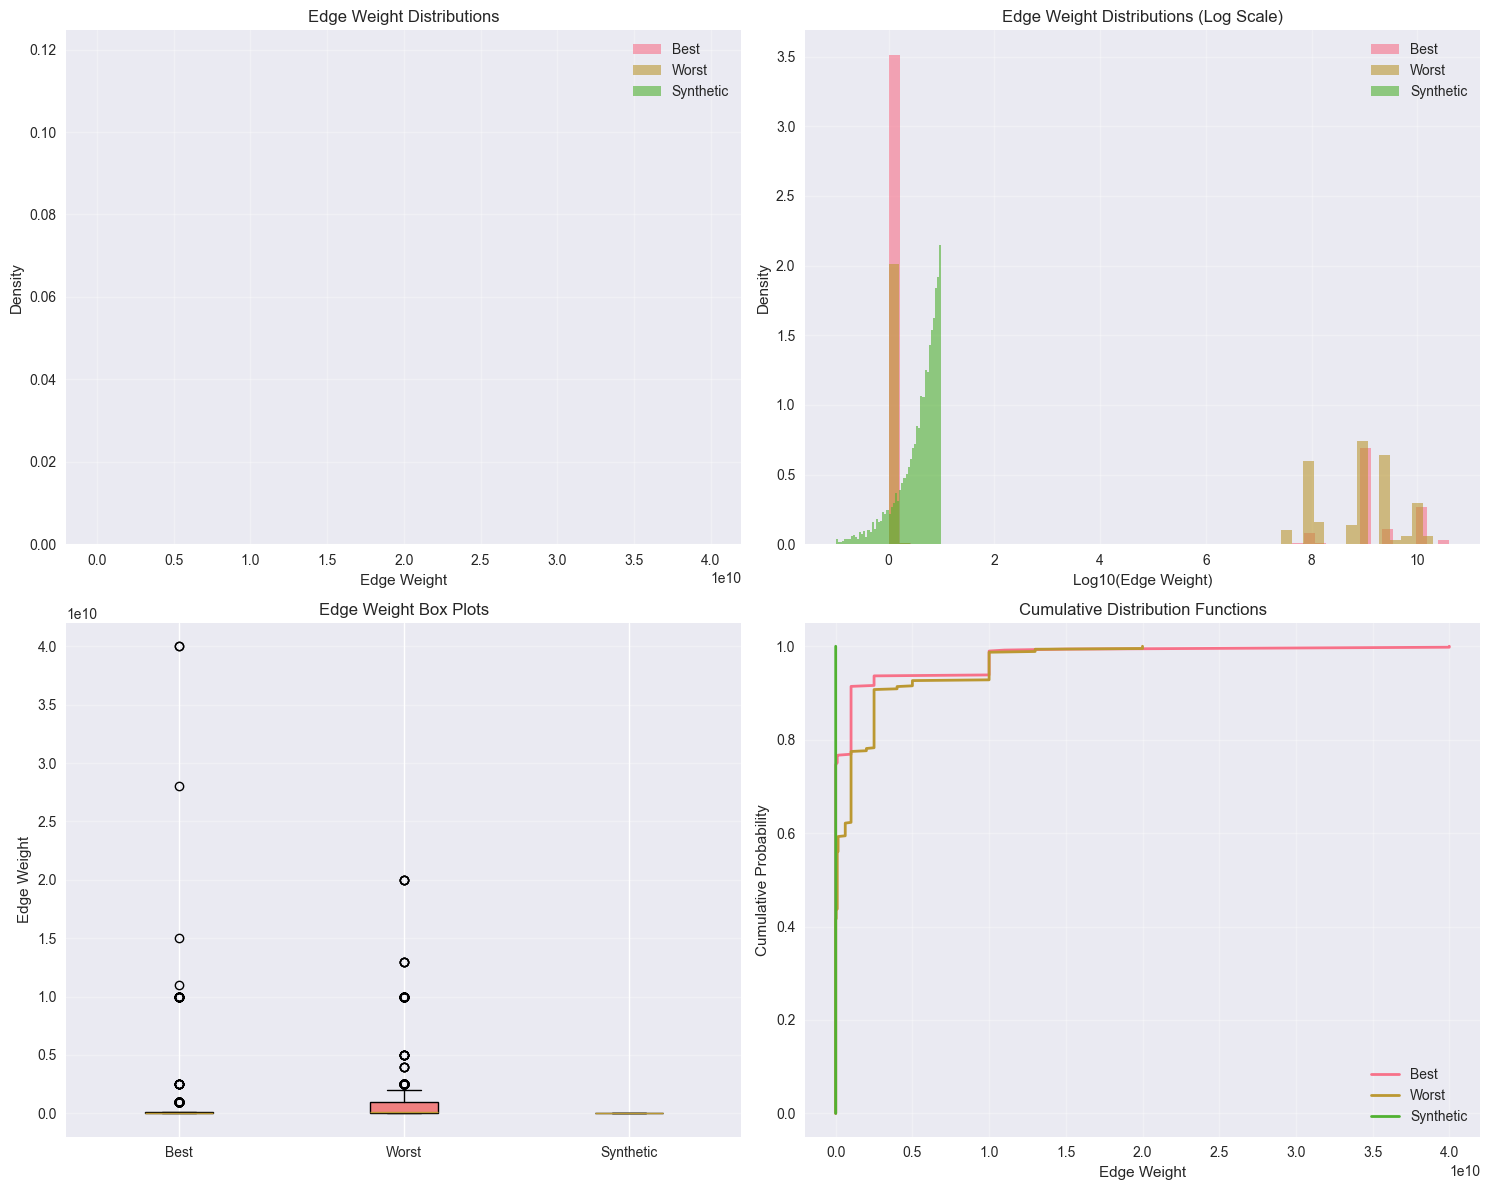

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram comparison
ax = axes[0, 0]
ax.hist(all_best_weights, bins=50, alpha=0.6, label="Best", density=True)
ax.hist(all_worst_weights, bins=50, alpha=0.6, label="Worst", density=True)
ax.hist(synthetic_weights, bins=50, alpha=0.6, label="Synthetic", density=True)
ax.set_xlabel("Edge Weight")
ax.set_ylabel("Density")
ax.set_title("Edge Weight Distributions")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Log scale histogram
ax = axes[0, 1]
ax.hist(
    np.log10(all_best_weights + 1e-10), bins=50, alpha=0.6, label="Best", density=True
)
ax.hist(
    np.log10(all_worst_weights + 1e-10), bins=50, alpha=0.6, label="Worst", density=True
)
ax.hist(
    np.log10(synthetic_weights + 1e-10),
    bins=50,
    alpha=0.6,
    label="Synthetic",
    density=True,
)
ax.set_xlabel("Log10(Edge Weight)")
ax.set_ylabel("Density")
ax.set_title("Edge Weight Distributions (Log Scale)")
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Box plot comparison
ax = axes[1, 0]
data_to_plot = [all_best_weights, all_worst_weights, synthetic_weights]
bp = ax.boxplot(data_to_plot, labels=["Best", "Worst", "Synthetic"], patch_artist=True)
colors = ["lightblue", "lightcoral", "lightgreen"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_ylabel("Edge Weight")
ax.set_title("Edge Weight Box Plots")
ax.grid(True, alpha=0.3, axis="y")

# 4. CDF comparison
ax = axes[1, 1]
sorted_best = np.sort(all_best_weights)
sorted_worst = np.sort(all_worst_weights)
sorted_synthetic = np.sort(synthetic_weights)
ax.plot(sorted_best, np.linspace(0, 1, len(sorted_best)), label="Best", linewidth=2)
ax.plot(sorted_worst, np.linspace(0, 1, len(sorted_worst)), label="Worst", linewidth=2)
ax.plot(
    sorted_synthetic,
    np.linspace(0, 1, len(sorted_synthetic)),
    label="Synthetic",
    linewidth=2,
)
ax.set_xlabel("Edge Weight")
ax.set_ylabel("Cumulative Probability")
ax.set_title("Cumulative Distribution Functions")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Per-Network Weight Distributions and Correlation Analysis


In [17]:
# Create a detailed comparison table
comparison_data = []

for name, weights in best_weights.items():
    network_info = next(n for n in best_10 if n["name"] == name)
    comparison_data.append(
        {
            "name": name,
            "group": "Best",
            "mape": network_info["mape"],
            "mae": network_info["mae"],
            "nodes": network_info["num_nodes"],
            "edges": network_info["num_edges"],
            "weight_mean": weights.mean(),
            "weight_std": weights.std(),
            "weight_min": weights.min(),
            "weight_max": weights.max(),
            "weight_median": np.median(weights),
            "weight_cv": weights.std() / weights.mean() if weights.mean() > 0 else 0,
        }
    )

for name, weights in worst_weights.items():
    network_info = next(n for n in worst_10 if n["name"] == name)
    comparison_data.append(
        {
            "name": name,
            "group": "Worst",
            "mape": network_info["mape"],
            "mae": network_info["mae"],
            "nodes": network_info["num_nodes"],
            "edges": network_info["num_edges"],
            "weight_mean": weights.mean(),
            "weight_std": weights.std(),
            "weight_min": weights.min(),
            "weight_max": weights.max(),
            "weight_median": np.median(weights),
            "weight_cv": weights.std() / weights.mean() if weights.mean() > 0 else 0,
        }
    )

comparison_df = pd.DataFrame(comparison_data)

print("Per-Network Edge Weight Statistics:")
print(
    comparison_df.groupby("group").agg(
        {
            "weight_mean": ["mean", "std"],
            "weight_std": ["mean", "std"],
            "weight_cv": ["mean", "std"],
            "weight_min": "mean",
            "weight_max": "mean",
        }
    )
)

# Calculate correlations
print("\n" + "=" * 80)
print("Correlation between weight statistics and MAPE:")
print("\nAll Networks Combined:")
all_corr = (
    comparison_df[
        [
            "mape",
            "weight_mean",
            "weight_std",
            "weight_cv",
            "weight_min",
            "weight_max",
            "weight_median",
        ]
    ]
    .corr()["mape"]
    .sort_values(ascending=False)
)
print(all_corr)

Per-Network Edge Weight Statistics:
        weight_mean                  weight_std               weight_cv  \
               mean           std          mean           std      mean   
group                                                                     
Best   6.683287e+09  1.292636e+10  1.962605e+09  2.717720e+09  0.460013   
Worst  1.194131e+09  1.542201e+09  1.513621e+09  1.959065e+09  0.516595   

                   weight_min    weight_max  
            std          mean          mean  
group                                        
Best   0.664146  5.210000e+09  9.800000e+09  
Worst  0.670735  1.000000e+07  8.010000e+09  

Correlation between weight statistics and MAPE:

All Networks Combined:
mape             1.000000
weight_cv       -0.092538
weight_max      -0.171694
weight_std      -0.197903
weight_median   -0.257209
weight_min      -0.258011
weight_mean     -0.285567
Name: mape, dtype: float64


## Visualize Correlations


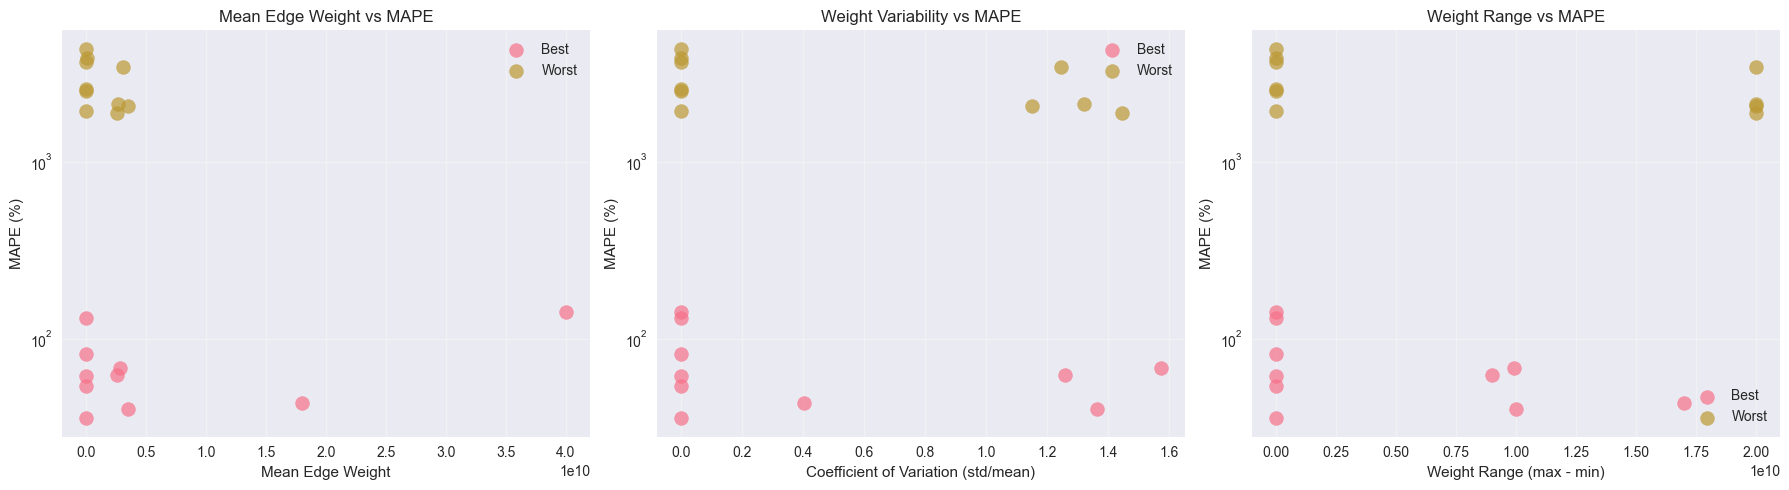

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Weight mean vs MAPE
ax = axes[0]
ax.scatter(
    comparison_df[comparison_df["group"] == "Best"]["weight_mean"],
    comparison_df[comparison_df["group"] == "Best"]["mape"],
    label="Best",
    alpha=0.7,
    s=100,
)
ax.scatter(
    comparison_df[comparison_df["group"] == "Worst"]["weight_mean"],
    comparison_df[comparison_df["group"] == "Worst"]["mape"],
    label="Worst",
    alpha=0.7,
    s=100,
)
ax.set_xlabel("Mean Edge Weight")
ax.set_ylabel("MAPE (%)")
ax.set_title("Mean Edge Weight vs MAPE")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

# 2. Weight CV vs MAPE
ax = axes[1]
ax.scatter(
    comparison_df[comparison_df["group"] == "Best"]["weight_cv"],
    comparison_df[comparison_df["group"] == "Best"]["mape"],
    label="Best",
    alpha=0.7,
    s=100,
)
ax.scatter(
    comparison_df[comparison_df["group"] == "Worst"]["weight_cv"],
    comparison_df[comparison_df["group"] == "Worst"]["mape"],
    label="Worst",
    alpha=0.7,
    s=100,
)
ax.set_xlabel("Coefficient of Variation (std/mean)")
ax.set_ylabel("MAPE (%)")
ax.set_title("Weight Variability vs MAPE")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

# 3. Weight range vs MAPE
comparison_df["weight_range"] = (
    comparison_df["weight_max"] - comparison_df["weight_min"]
)
ax = axes[2]
ax.scatter(
    comparison_df[comparison_df["group"] == "Best"]["weight_range"],
    comparison_df[comparison_df["group"] == "Best"]["mape"],
    label="Best",
    alpha=0.7,
    s=100,
)
ax.scatter(
    comparison_df[comparison_df["group"] == "Worst"]["weight_range"],
    comparison_df[comparison_df["group"] == "Worst"]["mape"],
    label="Worst",
    alpha=0.7,
    s=100,
)
ax.set_xlabel("Weight Range (max - min)")
ax.set_ylabel("MAPE (%)")
ax.set_title("Weight Range vs MAPE")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

plt.tight_layout()
plt.show()

## Statistical Tests


In [19]:
from scipy.stats import ks_2samp, mannwhitneyu

# Kolmogorov-Smirnov test for distribution differences
ks_stat_best_synthetic, ks_p_best_synthetic = ks_2samp(
    all_best_weights, synthetic_weights
)
ks_stat_worst_synthetic, ks_p_worst_synthetic = ks_2samp(
    all_worst_weights, synthetic_weights
)
ks_stat_best_worst, ks_p_best_worst = ks_2samp(all_best_weights, all_worst_weights)

print("Kolmogorov-Smirnov Tests (distribution similarity):")
print(f"\nBest vs Synthetic:")
print(f"  KS statistic: {ks_stat_best_synthetic:.4f}")
print(f"  p-value: {ks_p_best_synthetic:.4f}")
print(f"  {'Similar' if ks_p_best_synthetic > 0.05 else 'Different'} distributions")

print(f"\nWorst vs Synthetic:")
print(f"  KS statistic: {ks_stat_worst_synthetic:.4f}")
print(f"  p-value: {ks_p_worst_synthetic:.4f}")
print(f"  {'Similar' if ks_p_worst_synthetic > 0.05 else 'Different'} distributions")

print(f"\nBest vs Worst:")
print(f"  KS statistic: {ks_stat_best_worst:.4f}")
print(f"  p-value: {ks_p_best_worst:.4f}")
print(f"  {'Similar' if ks_p_best_worst > 0.05 else 'Different'} distributions")

# Mann-Whitney U test for median differences
mw_stat_best_worst, mw_p_best_worst = mannwhitneyu(
    all_best_weights, all_worst_weights, alternative="two-sided"
)

print(f"\nMann-Whitney U Test (median comparison):")
print(f"  Statistic: {mw_stat_best_worst:.4f}")
print(f"  p-value: {mw_p_best_worst:.4f}")
print(
    f"  Medians are {'similar' if mw_p_best_worst > 0.05 else 'significantly different'}"
)

Kolmogorov-Smirnov Tests (distribution similarity):

Best vs Synthetic:
  KS statistic: 0.6500
  p-value: 0.0000
  Different distributions

Worst vs Synthetic:
  KS statistic: 0.5837
  p-value: 0.0000
  Different distributions

Best vs Worst:
  KS statistic: 0.3307
  p-value: 0.0000
  Different distributions

Mann-Whitney U Test (median comparison):
  Statistic: 106929.5000
  p-value: 0.0000
  Medians are significantly different


## Summary and Insights


In [20]:
print("=" * 80)
print("SUMMARY OF FINDINGS")
print("=" * 80)

print("\n1. Weight Distribution Comparison:")
print(f"   - Best networks mean: {all_best_weights.mean():.4f}")
print(f"   - Worst networks mean: {all_worst_weights.mean():.4f}")
print(f"   - Synthetic mean: {synthetic_weights.mean():.4f}")

print("\n2. Weight Variability:")
print(f"   - Best networks CV: {all_best_weights.std()/all_best_weights.mean():.4f}")
print(f"   - Worst networks CV: {all_worst_weights.std()/all_worst_weights.mean():.4f}")
print(f"   - Synthetic CV: {synthetic_weights.std()/synthetic_weights.mean():.4f}")

print("\n3. Key Correlations:")
print(f"   - Weight mean vs MAPE: {all_corr['weight_mean']:.4f}")
print(f"   - Weight CV vs MAPE: {all_corr['weight_cv']:.4f}")
if "weight_range" in comparison_df.columns:
    print(
        f"   - Weight range vs MAPE: {comparison_df[['weight_range', 'mape']].corr().iloc[0,1]:.4f}"
    )

print("\n4. Statistical Significance:")
print(
    f"   - Best vs Worst distributions: {'Similar' if ks_p_best_worst > 0.05 else 'Different'} (p={ks_p_best_worst:.4f})"
)
print(
    f"   - Best vs Synthetic: {'Similar' if ks_p_best_synthetic > 0.05 else 'Different'} (p={ks_p_best_synthetic:.4f})"
)
print(
    f"   - Worst vs Synthetic: {'Similar' if ks_p_worst_synthetic > 0.05 else 'Different'} (p={ks_p_worst_synthetic:.4f})"
)

print("\n" + "=" * 80)
print("RECOMMENDATIONS")
print("=" * 80)

if ks_p_best_synthetic < ks_p_worst_synthetic:
    print(
        "\n✓ Best performing networks have weight distributions MORE similar to synthetic data"
    )
else:
    print(
        "\n✗ Best performing networks do NOT have weight distributions more similar to synthetic data"
    )

if abs(all_corr["weight_cv"]) > 0.3:
    print("\n✓ Weight variability (CV) shows significant correlation with performance")
    print(f"   Consider normalizing weights based on network-specific statistics")
else:
    print("\n✗ Weight variability does not show strong correlation with performance")

print("\nNext Steps:")
print("  1. Investigate path length distributions")
print("  2. Analyze edge weight normalization strategies")
print("  3. Consider network-specific weight scaling")
print("  4. Test training with diverse weight distributions")

SUMMARY OF FINDINGS

1. Weight Distribution Comparison:
   - Best networks mean: 1009183674.2184
   - Worst networks mean: 1422795853.6874
   - Synthetic mean: 4.9922

2. Weight Variability:
   - Best networks CV: 3.6289
   - Worst networks CV: 2.1163
   - Synthetic CV: 0.5704

3. Key Correlations:
   - Weight mean vs MAPE: -0.2856
   - Weight CV vs MAPE: -0.0925
   - Weight range vs MAPE: 0.0366

4. Statistical Significance:
   - Best vs Worst distributions: Different (p=0.0000)
   - Best vs Synthetic: Different (p=0.0000)
   - Worst vs Synthetic: Different (p=0.0000)

RECOMMENDATIONS

✓ Best performing networks have weight distributions MORE similar to synthetic data

✗ Weight variability does not show strong correlation with performance

Next Steps:
  1. Investigate path length distributions
  2. Analyze edge weight normalization strategies
  3. Consider network-specific weight scaling
  4. Test training with diverse weight distributions
